# Imports e Configuração

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix

TECNICA_ATUAL = "SMOTE" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = "X_train_pronto_SMOTE.csv"
NOME_Y_TRAIN = "y_train_pronto_SMOTE.csv"
NOME_X_TEST  = "X_test_pronto_SMOTE.csv"
NOME_Y_TEST  = "y_test_pronto_SMOTE.csv"

print(f"📗 Treinamento ENSEMBLE Soft Voting (RandomForest + GradientBoosting) - Dados: {TECNICA_ATUAL}")

📗 Treinamento ENSEMBLE (RandomForest + GradientBoosting) - Dados: SMOTE


# Carregamento

In [9]:
path_X_train = os.path.join(PASTA_DADOS, NOME_X_TRAIN)
path_y_train = os.path.join(PASTA_DADOS, NOME_Y_TRAIN)
path_X_test  = os.path.join(PASTA_DADOS, NOME_X_TEST)
path_y_test  = os.path.join(PASTA_DADOS, NOME_Y_TEST)

try:
    X_train = pd.read_csv(path_X_train)
    y_train = pd.read_csv(path_y_train).values.ravel()
    X_test = pd.read_csv(path_X_test)
    y_test = pd.read_csv(path_y_test).values.ravel()
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao ler arquivos: {e}")

Dados carregados com sucesso!


# Treinamento

In [10]:
clf_rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
clf_gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)

ensemble = VotingClassifier(estimators=[('RF', clf_rf), ('GB', clf_gb)], voting='soft')

ensemble.fit(X_train, y_train)
print("✅ Treinamento Concluído!")

✅ Treinamento Concluído!


# Avaliação

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.91      0.86      0.88       138
 Benigno (1)       0.79      0.73      0.76       142
  Câncer (2)       0.09      0.23      0.13        13

    accuracy                           0.77       293
   macro avg       0.60      0.61      0.59       293
weighted avg       0.82      0.77      0.79       293



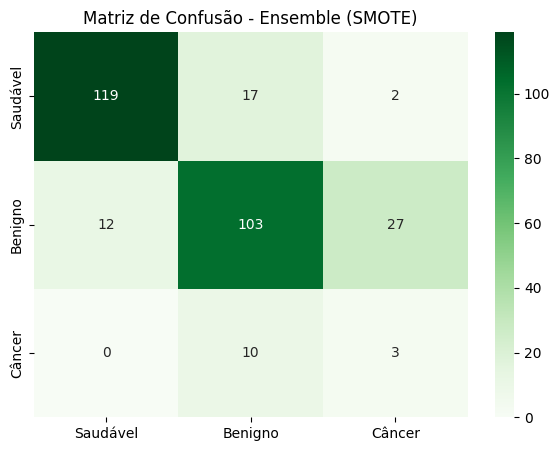

['..\\PreProcessing\\SMOTE\\modelo_ensemble_smote.pkl']

In [ ]:
y_pred = ensemble.predict(X_test)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Saudável', 'Benigno', 'Câncer'], yticklabels=['Saudável', 'Benigno', 'Câncer'])
plt.title(f"Matriz de Confusão - Ensemble (SMOTE)")
plt.show()

joblib.dump(ensemble, os.path.join(PASTA_DADOS, 'modelo_ensemble_smote_soft.pkl'))